1. Проверить что в первых формулах я использую координаты центра задней оси а не gps

In [1]:
l_car = 2.71
p = 3.675
l_off = 0.323
alpha = 0.154

## imports


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
import math
from scipy.linalg import inv
#oxts
from collections import namedtuple
import datetime as dt
import glob
import os
from google.colab import drive

from pathlib import Path
from typing import List, Tuple, Optional, Dict

In [3]:
drive.mount('/content/drive') #вылезет регистрация
# Путь к папке с ноутбуком
base_path = '/content/drive/MyDrive/Science work/Files'

Mounted at /content/drive


## функции


In [4]:
# Визуализация
def plot_trajectory(state: Dict[str, np.ndarray], frame_rate: float = 10.0):
    """
    Визуализация траектории

    Args:
        state: Словарь с данными состояния
        frame_rate: Частота кадров (Гц) для расчета времени
    """
    # Рассчитываем временную ось
    num_frames = len(state['x'])
    time_axis = np.arange(num_frames) / frame_rate  # Время в секундах

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    # 1. Траектория x-y с точками старта и финиша
    axes[0, 0].plot(state['x'], state['y'], 'b-', linewidth=1.5, alpha=0.8)
    # Зеленая точка старта
    axes[0, 0].plot(state['x'][0], state['y'][0], 'go',
                   markersize=12, label='Старт', zorder=5, markeredgewidth=2)
    # Красная точка финиша
    axes[0, 0].plot(state['x'][-1], state['y'][-1], 'ro',
                   markersize=12, label='Финиш', zorder=5, markeredgewidth=2)
    axes[0, 0].set_title('Траектория движения', fontsize=12, fontweight='bold')
    axes[0, 0].set_xlabel('X (м)', fontsize=10)
    axes[0, 0].set_ylabel('Y (м)', fontsize=10)
    axes[0, 0].grid(True, alpha=0.3)
    axes[0, 0].axis('equal')
    axes[0, 0].legend(fontsize=10, loc='best')

    # 2. Yaw во времени (в градусах)
    yaw_deg = np.degrees(state['yaw'])  # Конвертация в градусы
    axes[0, 1].plot(time_axis, yaw_deg, 'g-', linewidth=1.5)
    axes[0, 1].set_title('Угол курса (Yaw)', fontsize=12, fontweight='bold')
    axes[0, 1].set_xlabel('Время (с)', fontsize=10)
    axes[0, 1].set_ylabel('Yaw (°)', fontsize=10)
    axes[0, 1].grid(True, alpha=0.3)
    axes[0, 1].set_xlim(0, time_axis[-1])

    # 3. Скорость во времени
    axes[1, 0].plot(time_axis, state['vf'], 'r-', linewidth=1.5)
    axes[1, 0].set_title('Скорость вперед (Vf)', fontsize=12, fontweight='bold')
    axes[1, 0].set_xlabel('Время (с)', fontsize=10)
    axes[1, 0].set_ylabel('Vf (м/с)', fontsize=10)
    axes[1, 0].grid(True, alpha=0.3)
    axes[1, 0].set_xlim(0, time_axis[-1])

    # Добавляем информационную панель под графиками
    plt.figtext(0.5, 0.01,
                f"Частота кадров: {frame_rate} Гц | "
                f"Длительность: {time_axis[-1]:.1f} с | "
                f"Кадров: {num_frames} | "
                f"ΔX: {state['x'][-1] - state['x'][0]:.1f} м | "
                f"ΔY: {state['y'][-1] - state['y'][0]:.1f} м | "
                f"Vf ср.: {np.mean(state['vf']):.2f} ± {np.std(state['vf']):.2f} м/с",
                ha="center", fontsize=10,
                bbox=dict(boxstyle="round,pad=0.5", facecolor="lightgray", alpha=0.5))

    plt.suptitle(f'Анализ траектории движения',
                fontsize=14, fontweight='bold', y=0.98)
    plt.tight_layout(rect=[0, 0.05, 1, 0.96])  # Оставляем место для текста снизу
    plt.show()

    # Дополнительный график: раздельные X(t) и Y(t) если нужно
    fig2, (ax_x, ax_y) = plt.subplots(1, 2, figsize=(12, 5))

    # X во времени
    ax_x.plot(time_axis, state['x'], 'b-', linewidth=2)
    ax_x.set_title('Координата X', fontsize=12, fontweight='bold')
    ax_x.set_xlabel('Время (с)', fontsize=10)
    ax_x.set_ylabel('X (м)', fontsize=10)
    ax_x.grid(True, alpha=0.3)
    ax_x.set_xlim(0, time_axis[-1])

    # Y во времени
    ax_y.plot(time_axis, state['y'], 'g-', linewidth=2)
    ax_y.set_title('Координата Y', fontsize=12, fontweight='bold')
    ax_y.set_xlabel('Время (с)', fontsize=10)
    ax_y.set_ylabel('Y (м)', fontsize=10)
    ax_y.grid(True, alpha=0.3)
    ax_y.set_xlim(0, time_axis[-1])

    plt.suptitle('Координаты во времени', fontsize=14, fontweight='bold', y=0.98)
    plt.tight_layout()
    plt.show()

In [5]:
def plot_comparison(controls_array, trajectory_array, title="Сравнение траекторий"):
    # Создаем 4 отдельных графика
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 12))

    time = np.arange(controls_array.shape[0])

    # График 1: Траектории в XY-плоскости
    ax1.plot(controls_array[:, 0], controls_array[:, 1], 'b-', linewidth=2, label='GPS траектория')
    ax1.plot(trajectory_array[:, 0], trajectory_array[:, 1], 'r--', linewidth=2, label='Center траектория')
    ax1.plot(controls_array[0, 0], controls_array[0, 1], 'go', markersize=8, label='Start_G')
    ax1.plot(trajectory_array[0, 0], trajectory_array[0, 1], 'bo', markersize=8, label='Start_A')

    ax1.plot(controls_array[-1, 0], controls_array[-1, 1], 'ro', markersize=8, label='End (G)')
    ax1.plot(trajectory_array[-1, 0], trajectory_array[-1, 1], 'mo', markersize=8, label='End (A)')
    ax1.set_xlabel('X (м)')
    ax1.set_ylabel('Y (м)')
    ax1.set_title('Сравнение траекторий в XY-плоскости')
    ax1.legend()
    ax1.grid(True)
    ax1.axis('equal')



In [6]:
def plot_vehicle_states_custom(states_array, y_scale_factors=None):
    """Визуализация с настраиваемым масштабом по Y для каждого графика."""
    if y_scale_factors is None:
        y_scale_factors = {
            'trajectory': 2.0, 'heading': 1.2, 'speed': 1.3,
            'steering': 1.5, 'coordinates': 1.2
        }

    time = np.arange(len(states_array)) * 0.1

    # Увеличиваем количество графиков до 6 (добавили координаты X и Y по времени)
    num_plots = min(states_array.shape[1] + 2, 6)  # +2 для отдельных графиков координат
    rows = (num_plots + 1) // 2
    fig, axes = plt.subplots(rows, 2, figsize=(16, 6 * rows))
    axes = axes.flatten() if rows > 1 else [axes] if num_plots > 1 else [[axes]]

    plot_idx = 0

    # 1. Траектория (X-Y)
    if plot_idx < len(axes):
        ax = axes[plot_idx]
        x, y = states_array[:, 0], states_array[:, 1]
        ax.plot(x, y, 'b-', linewidth=2.5)
        ax.plot(x[0], y[0], 'go', markersize=8, label='Старт')
        ax.plot(x[-1], y[-1], 'ro', markersize=8, label='Финиш')

        # Применяем масштабирование по Y
        x_center, y_center = (np.max(x) + np.min(x)) / 2, (np.max(y) + np.min(y)) / 2
        x_range, y_range = np.max(x) - np.min(x), np.max(y) - np.min(y)
        scale = y_scale_factors['trajectory']

        ax.set_xlim([x_center - x_range/2, x_center + x_range/2])
        ax.set_ylim([y_center - y_range/2 * scale, y_center + y_range/2 * scale])

        ax.set_xlabel('X координата (м)')
        ax.set_ylabel('Y координата (м)')
        ax.set_title(f'Траектория движения (масштаб Y: {scale}x)')
        ax.legend()
        ax.grid(True, alpha=0.3)
        plot_idx += 1

    # 2. Координата X во времени
    if plot_idx < len(axes):
        ax = axes[plot_idx]
        x_coords = states_array[:, 0]
        ax.plot(time, x_coords, 'r-', linewidth=2, label='X координата')

        # Масштабирование по Y
        y_range = np.max(x_coords) - np.min(x_coords)
        if y_range > 0:
            y_center = (np.max(x_coords) + np.min(x_coords)) / 2
            scale = y_scale_factors['coordinates']
            ax.set_ylim([y_center - y_range/2 * scale, y_center + y_range/2 * scale])

        ax.set_xlabel('Время (с)')
        ax.set_ylabel('X координата (м)')
        ax.set_title('Координата X во времени')
        ax.legend()
        ax.grid(True, alpha=0.3)
        plot_idx += 1

    # 3. Координата Y во времени
    if plot_idx < len(axes):
        ax = axes[plot_idx]
        y_coords = states_array[:, 1]
        ax.plot(time, y_coords, 'b-', linewidth=2, label='Y координата')

        # Масштабирование по Y
        y_range = np.max(y_coords) - np.min(y_coords)
        if y_range > 0:
            y_center = (np.max(y_coords) + np.min(y_coords)) / 2
            scale = y_scale_factors['coordinates']
            ax.set_ylim([y_center - y_range/2 * scale, y_center + y_range/2 * scale])

        ax.set_xlabel('Время (с)')
        ax.set_ylabel('Y координата (м)')
        ax.set_title('Координата Y во времени')
        ax.legend()
        ax.grid(True, alpha=0.3)
        plot_idx += 1

    # 4. Курс
    if plot_idx < len(axes) and states_array.shape[1] > 2:
        ax = axes[plot_idx]
        heading_deg = np.degrees(states_array[:, 2])
        ax.plot(time, heading_deg, 'g-', linewidth=2)

        # Масштабирование по Y
        y_range = np.max(heading_deg) - np.min(heading_deg)
        if y_range > 0:
            y_center = (np.max(heading_deg) + np.min(heading_deg)) / 2
            scale = y_scale_factors['heading']
            ax.set_ylim([y_center - y_range/2 * scale, y_center + y_range/2 * scale])

        ax.set_xlabel('Время (с)')
        ax.set_ylabel('Курс (°)')
        ax.set_title('Угол курса')
        ax.grid(True, alpha=0.3)
        plot_idx += 1

    # 5. Скорость
    if plot_idx < len(axes) and states_array.shape[1] > 3:
        ax = axes[plot_idx]
        speed_kmh = states_array[:, 3] * 3.6
        ax.plot(time, speed_kmh, 'orange', linewidth=2)

        # Масштабирование по Y
        y_range = np.max(speed_kmh) - np.min(speed_kmh)
        if y_range > 0:
            y_center = (np.max(speed_kmh) + np.min(speed_kmh)) / 2
            scale = y_scale_factors['speed']
            ax.set_ylim([max(0, y_center - y_range/2 * scale), y_center + y_range/2 * scale])

        ax.set_xlabel('Время (с)')
        ax.set_ylabel('Скорость (км/ч)')
        ax.set_title('Скорость движения')
        ax.grid(True, alpha=0.3)
        plot_idx += 1

    # 6. Угол поворота
    if plot_idx < len(axes) and states_array.shape[1] > 4:
        ax = axes[plot_idx]
        steering_deg = np.degrees(states_array[:, 4])
        ax.plot(time, steering_deg, 'm-', linewidth=2)

        # Масштабирование по Y
        y_range = np.max(steering_deg) - np.min(steering_deg)
        if y_range > 0:
            y_center = (np.max(steering_deg) + np.min(steering_deg)) / 2
            scale = y_scale_factors['steering']
            ax.set_ylim([y_center - y_range/2 * scale, y_center + y_range/2 * scale])

        ax.set_xlabel('Время (с)')
        ax.set_ylabel('Угол поворота (°)')
        ax.set_title('Угол поворота руля')
        ax.grid(True, alpha=0.3)
        plot_idx += 1

    # Скрываем пустые subplots
    for i in range(plot_idx, len(axes)):
        axes[i].set_visible(False)

    plt.tight_layout()
    plt.show()

In [7]:
def plot_trajectory_comparison(controls_array, trajectory_array, title="Сравнение траекторий"):
    """
    Визуализирует сравнение траекторий из controls_array и trajectory_array

    Parameters:
    -----------
    controls_array : numpy.ndarray shape (n, 5)
        Исходный массив, первые две компоненты - x, y
    trajectory_array : numpy.ndarray shape (n, 3)
        Моделируемый массив траектории [x, y, theta]
    """

    # Создаем 4 отдельных графика
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 12))

    time = np.arange(controls_array.shape[0])

    # График 1: Траектории в XY-плоскости
    ax1.plot(controls_array[:, 0], controls_array[:, 1], 'b-', linewidth=2, label='Controls траектория')
    ax1.plot(trajectory_array[:, 0], trajectory_array[:, 1], 'r--', linewidth=2, label='Model траектория')
    ax1.plot(controls_array[0, 0], controls_array[0, 1], 'go', markersize=8, label='Start')
    ax1.plot(trajectory_array[0, 0], trajectory_array[0, 1], 'mo', markersize=8, label='Start(Model)')

    ax1.plot(controls_array[-1, 0], controls_array[-1, 1], 'ro', markersize=8, label='End (Controls)')
    ax1.plot(trajectory_array[-1, 0], trajectory_array[-1, 1], 'mo', markersize=8, label='End (Model)')
    ax1.set_xlabel('X (м)')
    ax1.set_ylabel('Y (м)')
    ax1.set_title('Сравнение траекторий в XY-плоскости')
    ax1.legend()
    ax1.grid(True)
    ax1.axis('equal')

    # График 2: Сравнение координат X
    ax2.plot(time, controls_array[:, 0], 'b-', linewidth=2, label='Controls X')
    ax2.plot(time, trajectory_array[:, 0], 'r--', linewidth=2, label='Model X')
    ax2.set_xlabel('Время (шаги)')
    ax2.set_ylabel('X координата (м)')
    ax2.set_title('Сравнение координат X')
    ax2.legend()
    ax2.grid(True)

    # График 3: Сравнение координат Y
    ax3.plot(time, controls_array[:, 1], 'b-', linewidth=2, label='Controls Y')
    ax3.plot(time, trajectory_array[:, 1], 'r--', linewidth=2, label='Model Y')
    ax3.set_xlabel('Время (шаги)')
    ax3.set_ylabel('Y координата (м)')
    ax3.set_title('Сравнение координат Y')
    ax3.legend()
    ax3.grid(True)

    # График 4: Сравнение углов theta
    # Предполагаем, что в controls_array theta может быть в 3-м столбце (индекс 2)
    if controls_array.shape[1] >= 3:
        ax4.plot(time, np.degrees(controls_array[:, 2]), 'b-', linewidth=2, label='Controls θ')
    ax4.plot(time, np.degrees(trajectory_array[:, 2]), 'r--', linewidth=2, label='Model θ')
    ax4.set_xlabel('Время (шаги)')
    ax4.set_ylabel('Угол θ (градусы)')
    ax4.set_title('Сравнение углов ориентации θ')
    ax4.legend()
    ax4.grid(True)

    plt.tight_layout()
    plt.show()


    # Визуализация угла
    plt.figure(figsize=(14, 6))
    plt.plot(time, np.degrees(trajectory_array[:,-1]), 'b-', linewidth=1.5)
    plt.title('Угол поворота руля φ (ограничен ±50°)', fontsize=12, fontweight='bold')
    plt.xlabel('Время (с)', fontsize=10)
    plt.ylabel('φ (°)', fontsize=10)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.xlim(0, time[-1])
    plt.show()

    # Вычисляем метрики ошибок
    print("="*50)
    print("МЕТРИКИ СРАВНЕНИЯ ТРАЕКТОРИЙ")
    print("="*50)

    # RMSE для координат
    rmse_x = np.sqrt(np.mean((controls_array[:, 0] - trajectory_array[:, 0])**2))
    rmse_y = np.sqrt(np.mean((controls_array[:, 1] - trajectory_array[:, 1])**2))

    print(f"RMSE по X: {rmse_x:.4f} м")
    print(f"RMSE по Y: {rmse_y:.4f} м")
    print(f"Общий RMSE: {np.sqrt(rmse_x**2 + rmse_y**2):.4f} м")

    # Максимальные ошибки
    max_error_x = np.max(np.abs(controls_array[:, 0] - trajectory_array[:, 0]))
    max_error_y = np.max(np.abs(controls_array[:, 1] - trajectory_array[:, 1]))

    print(f"Максимальная ошибка по X: {max_error_x:.4f} м")
    print(f"Максимальная ошибка по Y: {max_error_y:.4f} м")

    # Сравнение конечных позиций
    final_pos_controls = controls_array[-1, :2]
    final_pos_model = trajectory_array[-1, :2]
    final_distance = np.linalg.norm(final_pos_controls - final_pos_model)

    print(f"Конечная позиция Controls: ({final_pos_controls[0]:.2f}, {final_pos_controls[1]:.2f}) м")
    print(f"Конечная позиция Model:    ({final_pos_model[0]:.2f}, {final_pos_model[1]:.2f}) м")
    print(f"Расстояние между конечными точками: {final_distance:.4f} м")

# Парсим


## класс для парсинга

In [8]:
class KittiOxtsParser:
    """
    Парсер и калибратор GPS/IMU данных KITTI
    """

    def __init__(self, base_path: str, date: str = '2011_09_30', drive: str = '0020'):
        """
        Инициализация парсера

        Args:
            base_path: Базовый путь к датасету KITTI
            date: Дата записи (формат: YYYY_MM_DD)
            drive: Номер поездки
        """
        self.base_path = Path(base_path)
        self.date = date
        self.drive = drive

        # Структура папок (должна существовать)
        self.sequence_dir = self.base_path / f"{date}_drive_{drive}_sync"
        self.oxts_dir = self.sequence_dir / "oxts"
        self.data_dir = self.oxts_dir / "data"
        self.timestamps_file = self.oxts_dir / "timestamps.txt"

        # Проверка структуры
        self._check_structure()

        # Инициализация
        self.scale = None
        self.first_pose_inv = None
        self.oxts_data = None
        self.poses = None

    def _check_structure(self):
        """Проверка структуры папок и файлов"""
        required_dirs = [self.sequence_dir, self.oxts_dir, self.data_dir]
        required_files = [self.timestamps_file]

        for dir_path in required_dirs:
            if not dir_path.exists():
                raise FileNotFoundError(f"Директория не найдена: {dir_path}")

        for file_path in required_files:
            if not file_path.exists():
                raise FileNotFoundError(f"Файл не найден: {file_path}")

        # Проверка наличия файлов с данными
        data_files = list(self.data_dir.glob("*.txt"))
        if len(data_files) == 0:
            raise FileNotFoundError(f"Нет файлов с данными в {self.data_dir}")

        print(f"Структура OK: найдено {len(data_files)} файлов с данными")

    @staticmethod
    def lat_to_scale(lat_deg: float) -> float:
        """
        Вычисление масштаба Меркатора из широты

        Args:
            lat_deg: Широта в градусах

        Returns:
            Масштабный коэффициент
        """
        return math.cos(lat_deg * math.pi / 180.0)

    @staticmethod
    def latlon_to_mercator(lat_deg: float, lon_deg: float, scale: float) -> Tuple[float, float]:
        """
        Преобразование географических координат в координаты Меркатора

        Args:
            lat_deg: Широта в градусах
            lon_deg: Долгота в градусах
            scale: Масштабный коэффициент

        Returns:
            Координаты (x, y) в метрах
        """
        earth_radius = 6378137.0  # радиус Земли в метрах

        # Преобразование в метры
        mx = scale * lon_deg * math.pi * earth_radius / 180.0
        my = scale * earth_radius * math.log(
            math.tan((90.0 + lat_deg) * math.pi / 360.0)
        )

        return mx, my

    @staticmethod
    def wrap_to_pi(angle: float) -> float:
        """
        Нормализация угла в диапазон [-π, π]

        Args:
            angle: Угол в радианах

        Returns:
            Нормализованный угол
        """
        # Оборачиваем в [0, 2π]
        angle = angle % (2 * math.pi)

        # Оборачиваем в [-π, π]
        if angle > math.pi:
            angle -= 2 * math.pi

        return angle

    def load_oxts_data(self, frames: Optional[List[int]] = None) -> List[np.ndarray]:
        """
        Загрузка RAW GPS/IMU данных

        Args:
            frames: Список кадров для загрузки (None = все кадры)

        Returns:
            Список массивов с 30 параметрами для каждого кадра
        """
        if frames is None:
            # Загружаем все кадры
            num_frames = len(list(self.data_dir.glob("*.txt")))
            frames = list(range(num_frames))

        oxts_list = []

        for frame_idx in frames:
            file_name = self.data_dir / f"{frame_idx:010d}.txt"

            try:
                # Загружаем 30 значений из файла
                data = np.loadtxt(file_name)
                if data.ndim == 0:  # Если только одно значение
                    data = np.array([data])
                oxts_list.append(data)
            except Exception as e:
                print(f"Ошибка при загрузке {file_name}: {e}")
                oxts_list.append(np.array([]))

        self.oxts_data = oxts_list
        return oxts_list

    def convert_oxts_to_pose(self) -> List[np.ndarray]:
        """
        Преобразование OXTS измерений в метрические позы

        Returns:
            Список 4x4 матриц преобразования
        """
        if self.oxts_data is None:
            self.load_oxts_data()

        # Вычисляем масштаб из первой широты
        first_lat = self.oxts_data[0][0]
        self.scale = self.lat_to_scale(first_lat)

        poses = []
        first_pose_inv = None

        for i, oxts in enumerate(self.oxts_data):
            # Если нет данных - пропускаем
            if len(oxts) == 0:
                poses.append(np.array([]))
                continue

            # Извлекаем параметры
            lat, lon, alt = oxts[0], oxts[1], oxts[2]
            roll, pitch, yaw = oxts[3], oxts[4], oxts[5]

            # Вектор перевода (в координаты Меркатора)
            mx, my = self.latlon_to_mercator(lat, lon, self.scale)
            t = np.array([[mx], [my], [alt]])

            # Матрица поворота (OXTS RT3000 manual, стр. 71)
            Rx = np.array([
                [1, 0, 0],
                [0, math.cos(roll), -math.sin(roll)],
                [0, math.sin(roll), math.cos(roll)]
            ])  # base => nav

            Ry = np.array([
                [math.cos(pitch), 0, math.sin(pitch)],
                [0, 1, 0],
                [-math.sin(pitch), 0, math.cos(pitch)]
            ])  # base => nav

            Rz = np.array([
                [math.cos(yaw), -math.sin(yaw), 0],
                [math.sin(yaw), math.cos(yaw), 0],
                [0, 0, 1]
            ])  # base => nav

            R = Rz @ Ry @ Rx

            # Создаем матрицу преобразования 4x4
            T = np.eye(4)
            T[:3, :3] = R
            T[:3, 3] = t.flatten()

            # Нормализуем (первая поза = начало координат)
            if first_pose_inv is None:
                first_pose_inv = np.linalg.inv(T)
                self.first_pose_inv = first_pose_inv

            # Преобразуем в координаты первой позы
            pose = first_pose_inv @ T
            poses.append(pose)

        self.poses = poses
        return poses

    def extract_vehicle_state(self) -> Dict[str, np.ndarray]:
        """
        Извлечение состояния транспортного средства: x, y, yaw, vf

        Returns:
            Словарь с массивами параметров
        """
        if self.poses is None:
            self.convert_oxts_to_pose()

        n = len(self.poses)
        x_coords = np.zeros(n)
        y_coords = np.zeros(n)
        yaw_angles = np.zeros(n)
        vf_speeds = np.zeros(n)

        for i in range(n):
            pose = self.poses[i]
            oxts = self.oxts_data[i]

            if len(pose) == 0 or len(oxts) == 0:
                x_coords[i] = np.nan
                y_coords[i] = np.nan
                yaw_angles[i] = np.nan
                vf_speeds[i] = np.nan
                continue

            # x, y из матрицы преобразования (трансляционная часть)
            x_coords[i] = pose[0, 3]
            y_coords[i] = pose[1, 3]

            # yaw (heading) из матрицы поворота
            R = pose[:3, :3]
            yaw_angles[i] = math.atan2(R[1, 0], R[0, 0])

            # vf (forward velocity) - 9-й элемент в OXTS данных (индекс 8)
            vf_speeds[i] = oxts[8] if len(oxts) > 8 else 0.0

        # Нормализуем углы yaw
        yaw_angles = np.array([self.wrap_to_pi(angle) for angle in yaw_angles])

        # Удаляем NaN значения
        valid_mask = ~np.isnan(x_coords)
        x_coords = x_coords[valid_mask]
        y_coords = y_coords[valid_mask]
        yaw_angles = yaw_angles[valid_mask]
        vf_speeds = vf_speeds[valid_mask]

        return {
            'x': x_coords,
            'y': y_coords,
            'yaw': yaw_angles,
            'vf': vf_speeds,
            'num_frames': n,
            'valid_frames': len(x_coords)
        }

    def load_timestamps(self) -> List[float]:
        """
        Загрузка временных меток

        Returns:
            Список временных меток в секундах
        """
        timestamps = []

        with open(self.timestamps_file, 'r') as f:
            for line in f:
                line = line.strip()
                if not line:
                    continue

                # Парсим строку формата: 2011-09-30 13:03:41.123456789
                try:
                    # Упрощенный парсинг (можно улучшить)
                    parts = line.split()
                    time_str = parts[1]  # Время

                    # Преобразуем в секунды
                    h, m, s = time_str.split(':')
                    seconds = float(h) * 3600 + float(m) * 60 + float(s)
                    timestamps.append(seconds)
                except:
                    timestamps.append(0.0)

        return timestamps

    def get_trajectory(self) -> np.ndarray:
        """
        Получение траектории (x, y, yaw)

        Returns:
            Массив формы (n, 3) с координатами и углом
        """
        state = self.extract_vehicle_state()
        return np.column_stack([state['x'], state['y'], state['yaw']])




In [9]:
# Пример использования
def main(base_path, date, drive):
    # Укажите правильный путь к вашему датасету KITTI
    BASE_PATH = base_path  # ИЗМЕНИТЕ ЭТОТ ПУТЬ!

    # Создаем парсер
    parser = KittiOxtsParser(
        base_path=BASE_PATH,
        date=date,
        drive=drive
    )

    # Загружаем и преобразуем данные
    print("Загрузка GPS/IMU данных...")
    oxts_data = parser.load_oxts_data()
    print(f"Загружено {len(oxts_data)} кадров")

    print("Преобразование в позы...")
    poses = parser.convert_oxts_to_pose()

    print("Извлечение состояния...")
    state = parser.extract_vehicle_state()

    # Вывод статистики
    print("\n=== Статистика ===")
    print(f"Всего кадров: {state['num_frames']}")
    print(f"Валидных кадров: {state['valid_frames']}")
    print(f"Диапазон X: [{state['x'].min():.2f}, {state['x'].max():.2f}] м")
    print(f"Диапазон Y: [{state['y'].min():.2f}, {state['y'].max():.2f}] м")
    print(f"Диапазон Yaw: [{state['yaw'].min():.2f}, {state['yaw'].max():.2f}] рад")
    print(f"Диапазон Vf: [{state['vf'].min():.2f}, {state['vf'].max():.2f}] м/с")

    # Получаем траекторию
    trajectory = parser.get_trajectory()
    print(f"\nТраектория shape: {trajectory.shape}")

    return parser, state, trajectory



## импорт gps/imu данных

In [10]:
# Запуск парсера
date='2011_09_30'
drive='0018'
parser, state, state_X = main(base_path, date, drive)


Структура OK: найдено 2762 файлов с данными
Загрузка GPS/IMU данных...
Загружено 2762 кадров
Преобразование в позы...
Извлечение состояния...

=== Статистика ===
Всего кадров: 2762
Валидных кадров: 2762
Диапазон X: [-54.17, 371.37] м
Диапазон Y: [-226.90, 252.40] м
Диапазон Yaw: [-3.14, 3.14] рад
Диапазон Vf: [-0.12, 11.65] м/с

Траектория shape: (2762, 3)


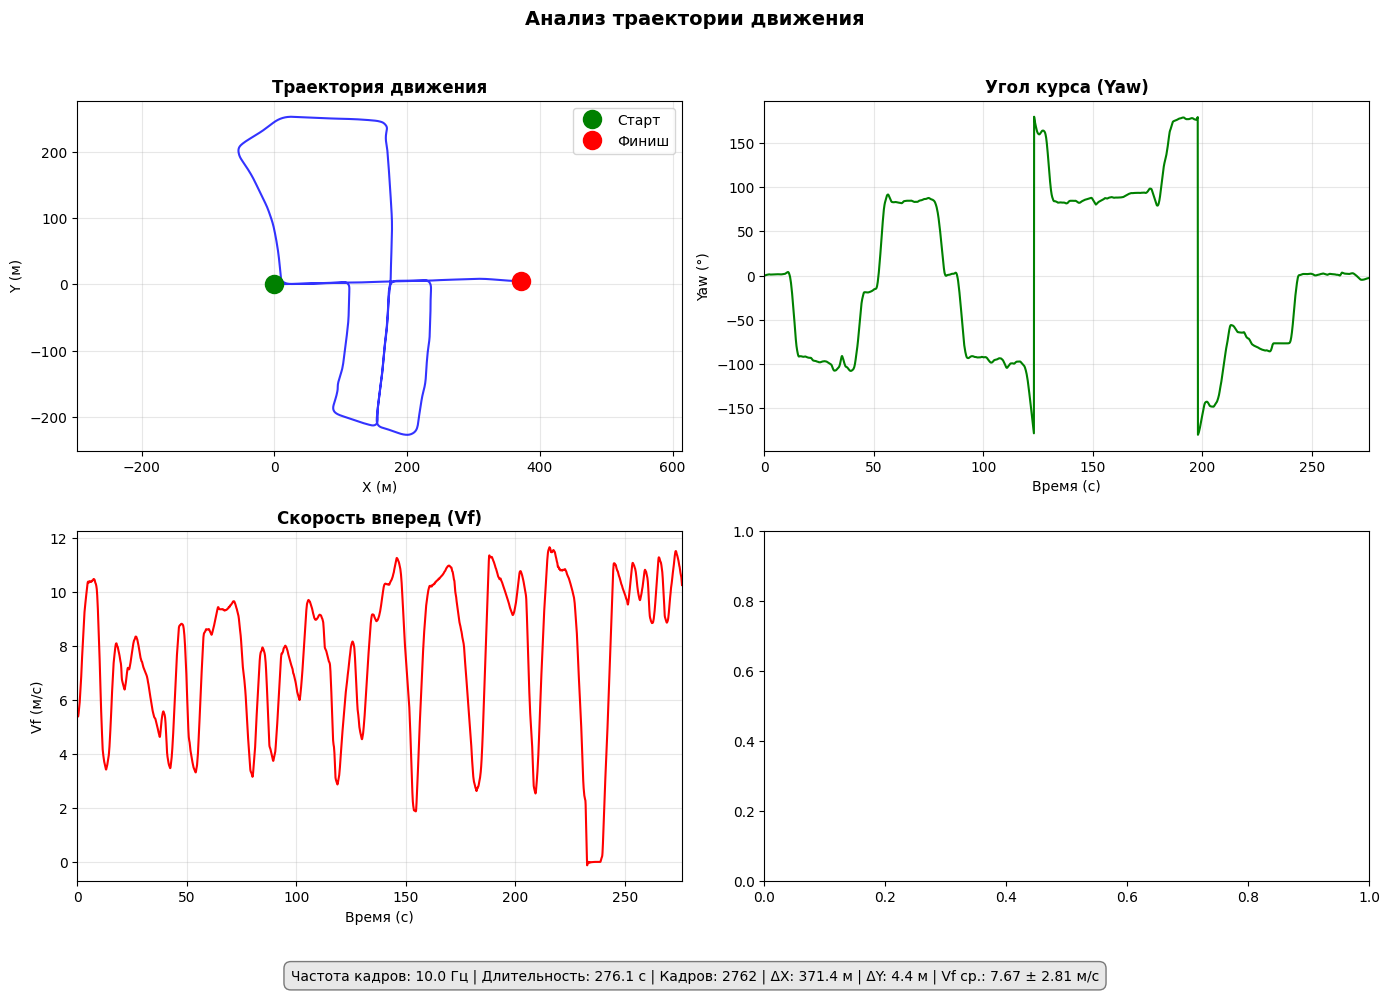

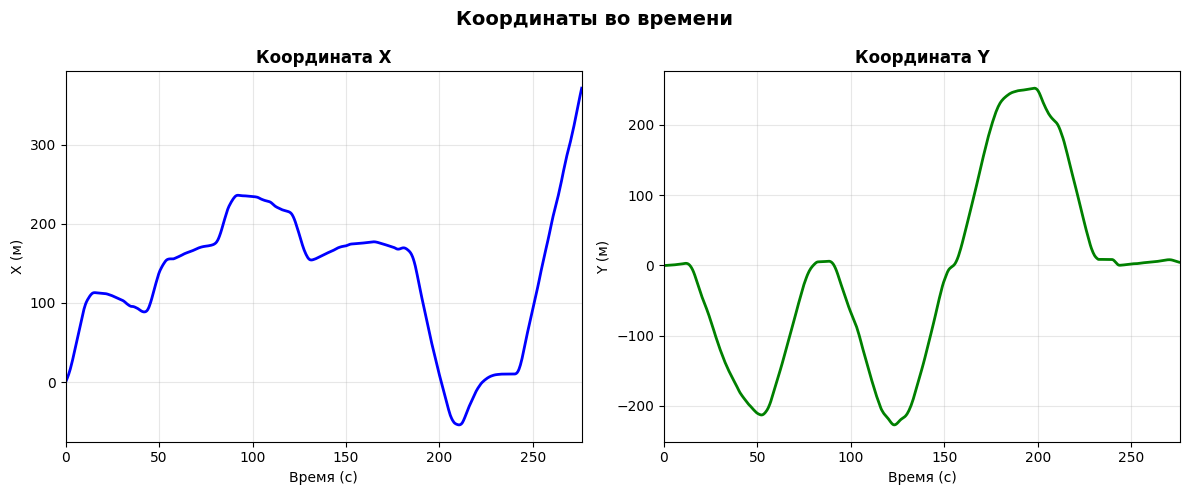

In [11]:
plot_trajectory(state)

# Расчёт фи

### Способ 1 (переход в систему координат привязанную к машине) - что-то похожее на правду

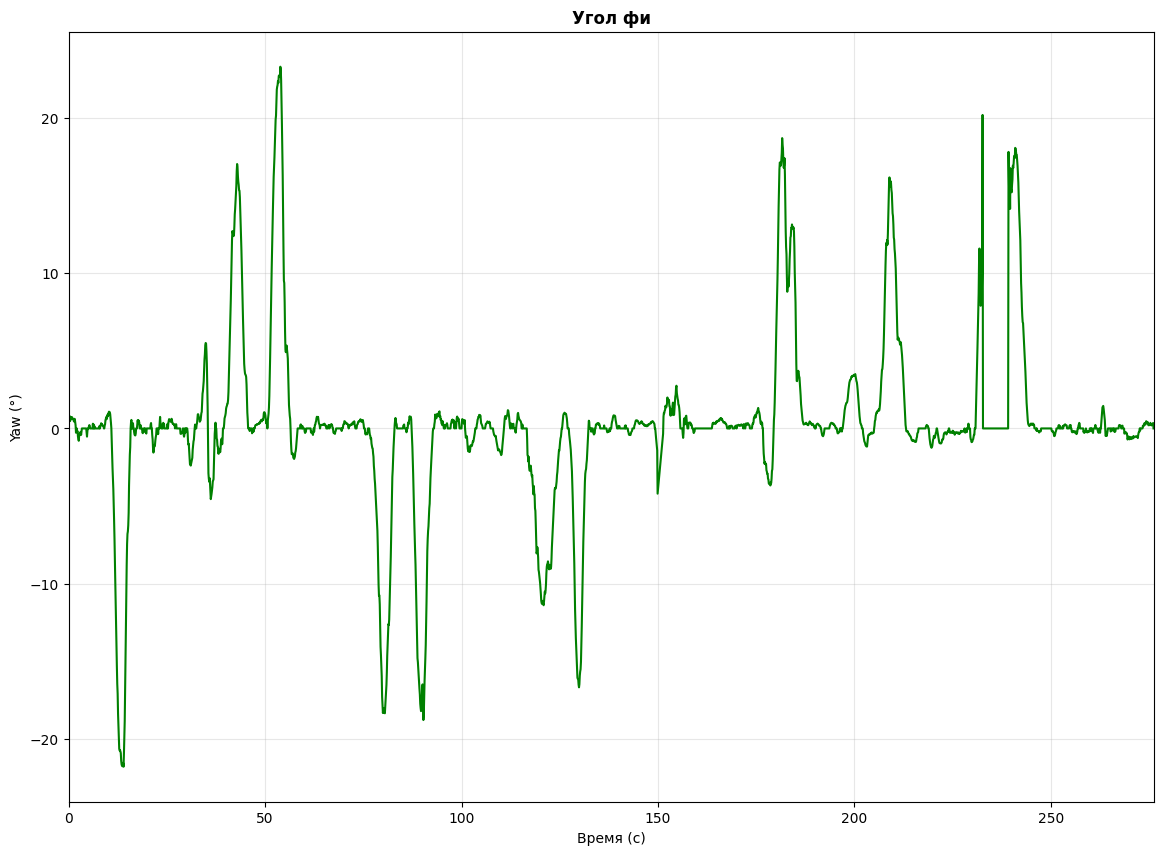

In [ ]:

# Способ 1 расчёта угла фи - условие на угол при Δy=0 -> φ=0

# 1) Находим координаты точек A в каждый момент времени в системе координат GPS (глобальной)
def step1_get_ABcords(state_x, mx = 3.724, my = -0.32):
  n = state_x.shape[0]
  cords_AB = np.zeros((n, 3))
  for i in range(n):
    teta = state_x[i, 2]
    #teta = np.arctan2(np.sin(teta), np.cos(teta))

    x_gps = mx * np.cos(teta) - my * np.sin(teta) + state_x[i, 0]
    y_gps = mx * np.sin(teta) + my * np.cos(teta) + state_x[i, 1]
    cords_AB[i] = [x_gps, y_gps, teta]

  return cords_AB

# 2) Переводим координаты В в системе координат GPS в систему координат машины где А(0, 0) -> B(x, y) это искомые dx, dy
def step2_get_Bcar(cords_A, state_x, mx = 3.724, my = -0.32):
  n = cords_A.shape[0]
  cords_B = np.zeros((n, 2))
  for i in range(1, n):
    teta = cords_A[i-1, 2]
    x_g = cords_A[i-1, 0]
    y_g = cords_A[i-1, 1]
    x_gps = cords_A[i, 0]
    y_gps = cords_A[i, 1]
    x_car = (x_gps - x_g)* np.cos(teta) + (y_gps - y_g)* np.sin(teta)
    y_car = - (x_gps - x_g) * np.sin(teta) + (y_gps - y_g) * np.cos(teta)
    # считаем дельты координат
    cords_B[i-1] = [x_car, y_car]

  return cords_B

# 3) Считаем углы фи по формуле Almeida (5)
def step3_get_phi_formula_5(cords_B, l_car, p):
  n = cords_B.shape[0]
  arr_phi = np.zeros(n)
  for i in range(n-1):
    dx_new = cords_B[i, 0]
    dy_new = cords_B[i, 1]
    #1. Проверка на малые перемещения
    if abs(dx_new) < 1e-3 and abs(dy_new) < 1e-3:
      arr_phi[i] = 0.0
      continue

    # 2. Особый случай dy ≈ 0 (прямолинейное движение)
    if abs(dy_new) < 0.004:  # порог, можно настроить
      arr_phi[i] = 0.0
      continue

    phi = np.arctan2((2 * dy_new * l_car), (dy_new**2 + 2 * dx_new * p + dx_new**2))
    arr_phi[i] = phi
  return arr_phi


cords_AB = step1_get_ABcords(state_X, p + 0.05, -0.32)
cords_B = step2_get_Bcar(cords_AB, state_X, p + 0.05, -0.32)
arr_phi = step3_get_phi_formula_5(cords_B, l_car, p)

# Ограничение по физическим возможностям руля
#phi_max = np.deg2rad(50)  # ±50 градусов
#arr_phi = np.clip(arr_phi, -phi_max, phi_max)


#Визуализируем угол
time_axis = np.arange(state_X.shape[0]) / 10  # Время в секундах

# Угол фи (yaw) во времени
yaw_deg = np.degrees(arr_phi)  # Конвертация радиан в градусы

plt.figure(figsize=(14, 10))
plt.plot(time_axis, yaw_deg, 'g-', linewidth=1.5)
plt.title('Угол фи', fontsize=12, fontweight='bold')
plt.xlabel('Время (с)', fontsize=10)
plt.ylabel('Yaw (°)', fontsize=10)
plt.grid(True, alpha=0.3)
plt.xlim(0, time_axis[-1])
plt.show()

## Моделируем

In [ ]:
def simulate_trajectory_from_controls(controls_array, l_car, dt=0.1):
    """
    Моделирует траекторию машины по управляющим воздействиям (скорость и угол руля)

    Parameters:
    -----------
    controls_array : numpy.ndarray shape (n, 5)
        Массив управляющих воздействий. Предполагается, что последние два столбца:
        [..., v, phi] где:
        v - линейная скорость (м/с)
        phi - угол поворота руля (радианы)
    l_car : float
        Колесная база vehicle в метрах
    dt : float
        Временной шаг между измерениями (секунды)

    Returns:
    --------
    trajectory : numpy.ndarray shape (n, 3)
        Массив траектории: [x, y, theta] для каждого временного шага
    """

    n = controls_array.shape[0]
    trajectory = np.zeros((n, 5))

    # Начальные условия (предполагаем начало в точке (0, 0, 0))
    x, y, theta = 0.0, 0.0, 0.0
    trajectory[0] = [x, y, theta,  controls_array[0, 3], controls_array[0, 4]]

    for k in range(n - 1):
        # Извлекаем скорость и угол поворота для текущего шага
        v_k = controls_array[k, 3]  # предпоследний столбец - скорость
        phi_k = controls_array[k, 4]  # последний столбец - угол поворота

        # Применяем уравнения движения
        x_next = np.cos(theta) * np.cos(phi_k) * v_k * dt + x
        y_next = np.sin(theta) * np.cos(phi_k) * v_k * dt + y
        theta_next = (np.sin(phi_k) * v_k * dt) / l_car + theta

        # Нормализуем угол theta в диапазон [-pi, pi]
        theta_next = np.arctan2(np.sin(theta_next), np.cos(theta_next))

        # Сохраняем следующее состояние
        trajectory[k + 1] = [x_next, y_next, theta_next, v_k, phi_k]

        # Обновляем текущее состояние для следующей итерации
        x, y, theta = x_next, y_next, theta_next

    return trajectory

Размерность входных данных: (2762, 5)
Размерность выходной траектории: (2762, 5)
Начальная точка: [0.         0.         0.         5.45013931 0.        ]
Конечная точка: [ 3.40990161e+02 -6.59223440e+01  3.21652606e-01  1.03613090e+01
  6.12759725e-03]


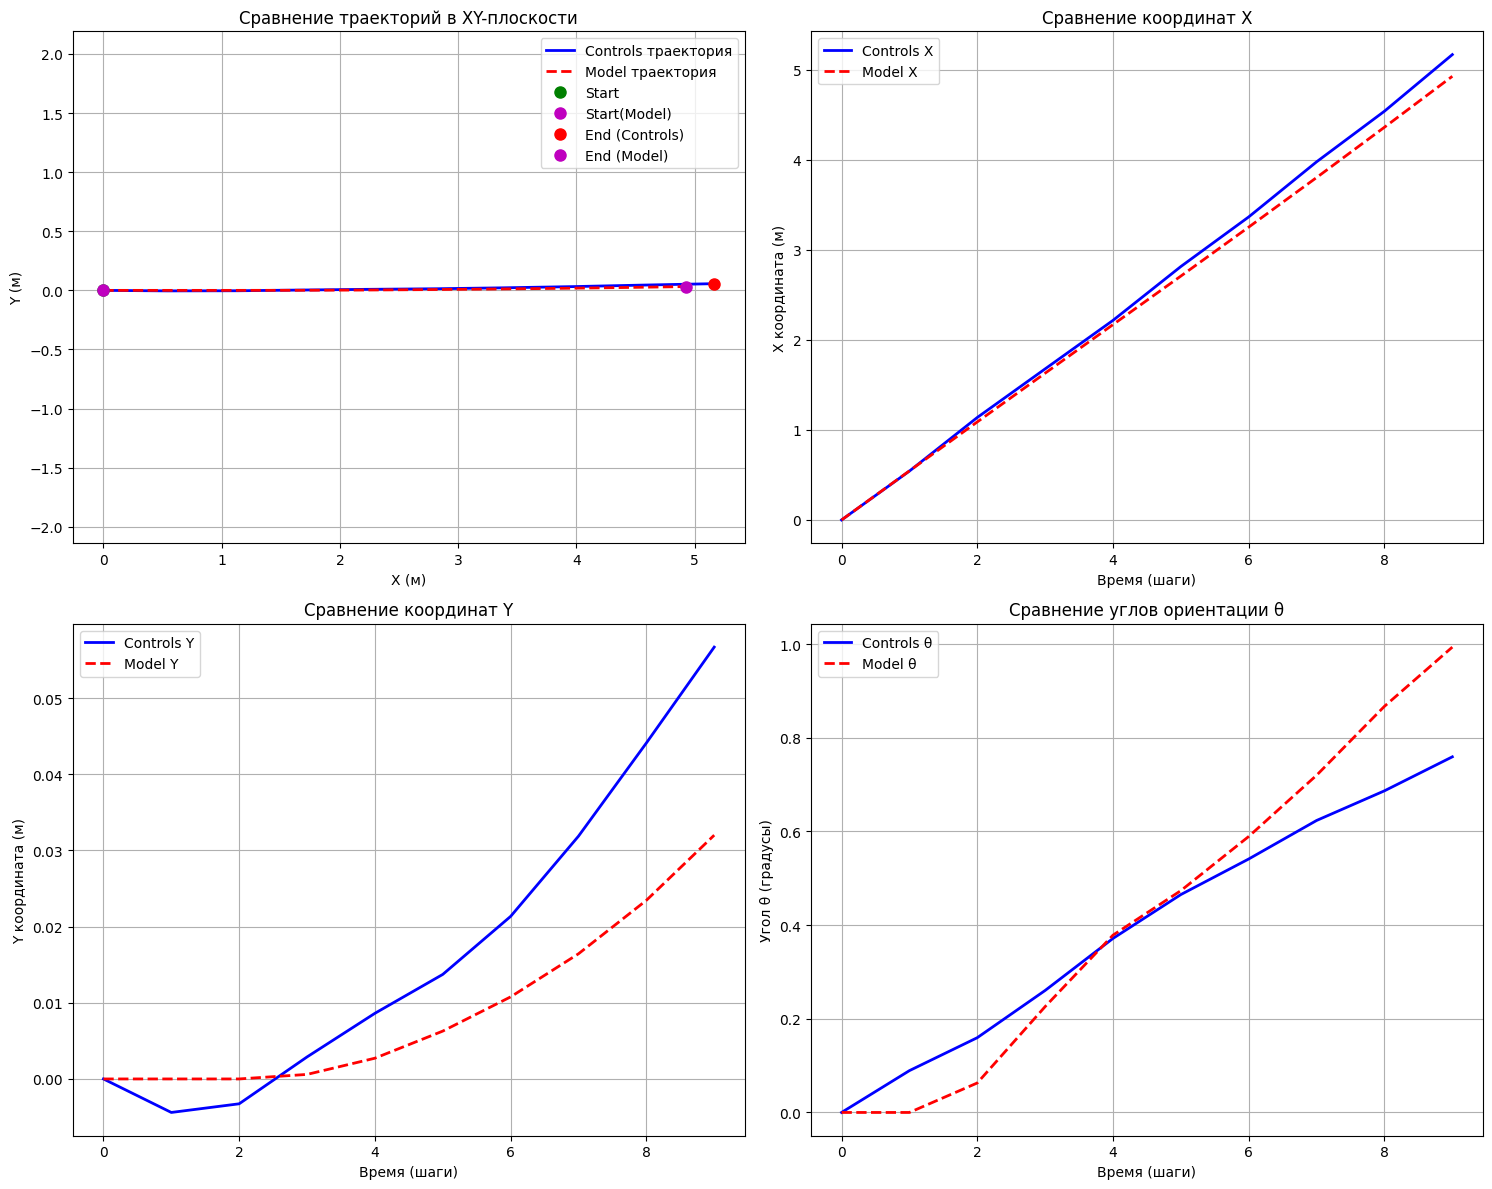

МЕТРИКИ СРАВНЕНИЯ ТРАЕКТОРИЙ
RMSE по X: 0.1229 м
RMSE по Y: 0.0123 м
Общий RMSE: 0.1235 м
Максимальная ошибка по X: 0.2407 м
Максимальная ошибка по Y: 0.0247 м
Конечная позиция Controls: (5.17, 0.06) м
Конечная позиция Model:    (4.92, 0.03) м
Расстояние между конечными точками: 0.2420 м


In [ ]:

# Создаём all_states = (n, 5): [x, y, teta, vf, phi]

n = state_X.shape[0]
all_states = np.zeros((n, 5))
all_states[:, :3] = state_X[:, :3]
all_states[:, 3] = state['vf']
all_states[:, 4] = arr_phi
# Моделируем траекторию
X_state_model = simulate_trajectory_from_controls(all_states, l_car=l_car, dt=0.1)

print(f"Размерность входных данных: {all_states.shape}")
print(f"Размерность выходной траектории: {X_state_model.shape}")
print(f"Начальная точка: {X_state_model[0]}")
print(f"Конечная точка: {X_state_model[-1]}")

# Визуализируем результаты
plot_trajectory_comparison(all_states[0:10], X_state_model[:10])

In [ ]:
def transform_to_gps_coords(X_state_model: np.ndarray,
                            l_off: float = 1.2,
                            alpha: float = 0.0) -> np.ndarray:
    """
    Преобразует состояние автомобиля (x, y, theta) в координаты GPS-антенны.

    Формулы:
        x_GPS = x - l_off * cos(theta - alpha)
        y_GPS = y - l_off * sin(theta - alpha)
        theta_GPS = theta

    Args:
        X_state_model : np.ndarray, shape (n, 5)
            Массив состояний [x, y, theta, vf, phi]
        l_off : float
            Расстояние от центра машины до GPS-антенны (в метрах). По умолчанию 1.2 м.
        alpha : float
            Угол смещения антенны относительно продольной оси машины (в радианах).
            По умолчанию 0 — антенна спереди по оси движения.

    Returns:
        X_gps : np.ndarray, shape (n, 3)
            Массив координат GPS: [x_gps, y_gps, theta_gps]
    """
    # Извлекаем x, y, theta
    x = X_state_model[:, 0]   # x-координата центра машины
    y = X_state_model[:, 1]   # y-координата центра машины
    theta = X_state_model[:, 2]  # угол поворота машины (yaw)

    # Вычисляем смещение в системе координат машины
    dx = l_off * np.cos(theta - alpha)
    dy = l_off * np.sin(theta - alpha)

    # Переводим в GPS-координаты
    x_gps = x - dx
    y_gps = y - dy
    theta_gps = theta  # угол не меняется

    # Собираем результат
    X_gps = np.column_stack([x_gps, y_gps, theta_gps])

    return X_gps


# Преобразуем в GPS-координаты
X_gps = transform_to_gps_coords(X_state_model, l_off=l_off, alpha=alpha)

print("GPS-координаты:")
#print(X_gps)
plot_trajectory_comparison(all_states[:10], X_gps[:10])

NameError: name 'alpha' is not defined

# Последний вариант

In [12]:
l_car = 2.5
p = 3.674
alpha = 0.47
l_off = 3.5
dt = 0.1

In [13]:
state_X_gps = state_X.copy()

### фи и модель


In [14]:
def simulate_trajectory_from_controls(controls_array, l_car, dt=0.1):
    """
    Моделирует траекторию машины по управляющим воздействиям (скорость и угол руля)

    Parameters:
    -----------
    controls_array : numpy.ndarray shape (n, 5)
        Массив управляющих воздействий. Предполагается, что последние два столбца:
        [..., v, phi] где:
        v - линейная скорость (м/с)
        phi - угол поворота руля (радианы)
    l_car : float
        Колесная база vehicle в метрах
    dt : float
        Временной шаг между измерениями (секунды)

    Returns:
    --------
    trajectory : numpy.ndarray shape (n, 3)
        Массив траектории: [x, y, theta] для каждого временного шага
    """

    n = controls_array.shape[0]
    trajectory = np.zeros((n, 5))

    # Начальные условия (предполагаем начало в точке (0, 0, 0))
    x, y, theta = 0.0, 0.0, 0.0
    x, y, theta = controls_array[0, :3]
    trajectory[0] = [x, y, theta,  controls_array[0, 3], controls_array[0, 4]]

    for k in range(n - 1):
        # Извлекаем скорость и угол поворота для текущего шага
        v_k = controls_array[k, 3]  # предпоследний столбец - скорость
        phi_k = controls_array[k, 4]  # последний столбец - угол поворота

        # Применяем уравнения движения
        x_next = np.cos(theta) * np.cos(phi_k) * v_k * dt + x
        y_next = np.sin(theta) * np.cos(phi_k) * v_k * dt + y
        theta_next = (np.sin(phi_k) * v_k * dt) / l_car + theta

        # Нормализуем угол theta в диапазон [-pi, pi]
        theta_next = np.arctan2(np.sin(theta_next), np.cos(theta_next))

        # Сохраняем следующее состояние
        trajectory[k + 1] = [x_next, y_next, theta_next, v_k, phi_k]

        # Обновляем текущее состояние для следующей итерации
        x, y, theta = x_next, y_next, theta_next

    return trajectory

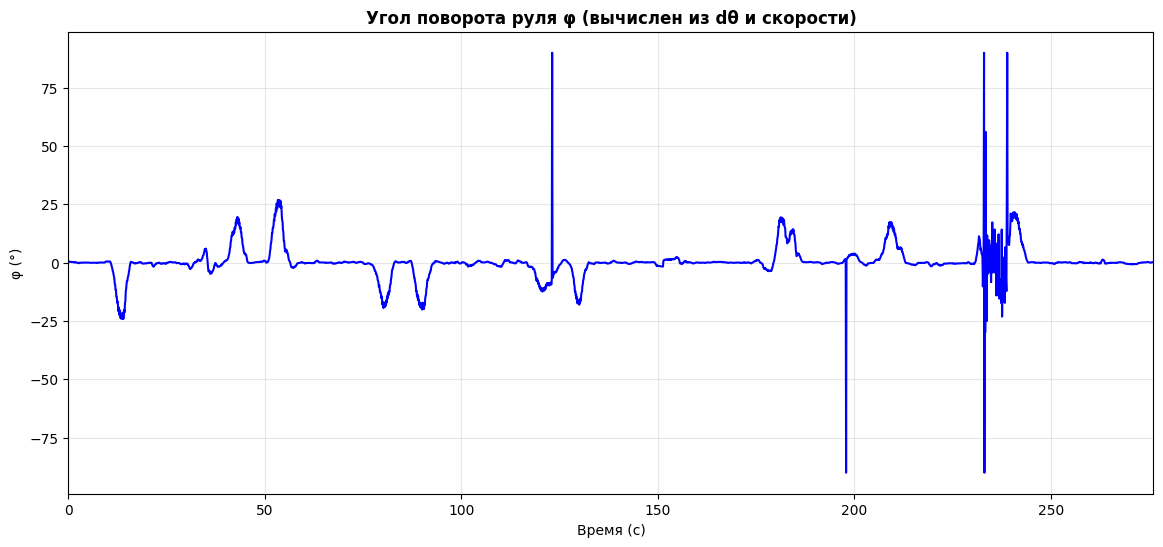

In [17]:
# Параметры
n = state_X.shape[0]

# Извлекаем данные
theta = state_X[:, 2]          # yaw (в радианах)
vf = state['vf']               # forward velocity (м/с)
# Вычисляем приращение угла dtheta

#Способ B
dtheta = np.diff(theta)
dtheta = np.where(dtheta > np.pi, dtheta - 2 * np.pi, dtheta)
dtheta = np.where(dtheta < -np.pi, dtheta + 2 * np.pi, dtheta)

#Способ А
theta_unwrapped = np.unwrap(theta, period=2*np.pi)
dtheta = np.diff(theta_unwrapped)

#Способ wrong
#dtheta = np.diff(theta)        # shape: (n-1,)
vf_valid = vf[:n-1]

# Вычисляем phi по формуле: phi = arctan( (l_car * dtheta) / (vf * dt) )
# Избегаем деления на ноль: если скорость мала — phi = 0
epsilon = 1e-3
denominator = vf_valid * dt
denominator = np.where(
    np.abs(denominator) < epsilon,
    np.copysign(epsilon, denominator),  # ← сохраняет знак исходного значения
    denominator
)
arg = l_car * dtheta / denominator
arg = np.clip(arg, -1.0, 1.0)
phi = np.arcsin(arg)

phi_full = np.zeros(n)
phi_full[:-1] = phi
phi_full[-1] = phi[-1] # или оставить phi_full[-1] = 0
arr_phi = phi_full

# Визуализация
time_axis = np.arange(n) * dt
plt.figure(figsize=(14, 6))
plt.plot(time_axis, np.degrees(arr_phi), 'b-', linewidth=1.5)
plt.title('Угол поворота руля φ (вычислен из dθ и скорости)', fontsize=12, fontweight='bold')
plt.xlabel('Время (с)', fontsize=10)
plt.ylabel('φ (°)', fontsize=10)
plt.grid(True, alpha=0.3)
plt.xlim(0, time_axis[-1])
plt.show()

### моделирование

In [18]:
def replace_xy_gps_to_xy_back_center(x_state, l_off, alpha):
  new_state = x_state.copy()
  a_angle = np.arctan(6.4)
  a_angle = alpha #+ 0.5 * np.pi
  new_state[:, 0] = new_state[:, 0] + l_off * np.cos(new_state[:, 2] - a_angle)
  new_state[:, 1] = new_state[:, 1] + l_off * np.sin(new_state[:, 2] - a_angle)

  return new_state

state_X_center = replace_xy_gps_to_xy_back_center(state_X_gps, l_off, alpha)


state_X = state_X_center
x, y, theta = state_X[0, :3]
print(x,y,theta)

n = state_X.shape[0]
all_states = np.zeros((n, 5))
all_states[:, :3] = state_X[:, :3]
all_states[:, 3] = state['vf']
all_states[:, 4] = arr_phi

3.12048900821799 -1.585101998826739 4.630179593222776e-18


Размерность входных данных: (2762, 5)
Размерность выходной траектории: (2762, 5)
Начальная точка: [ 3.12048901e+00 -1.58510200e+00  4.63017959e-18  5.45013931e+00
  7.15004309e-03]
Конечная точка: [ 2.09086149e+02 -9.19803949e+01 -1.29328553e-01  1.03613090e+01
  4.81520437e-03]


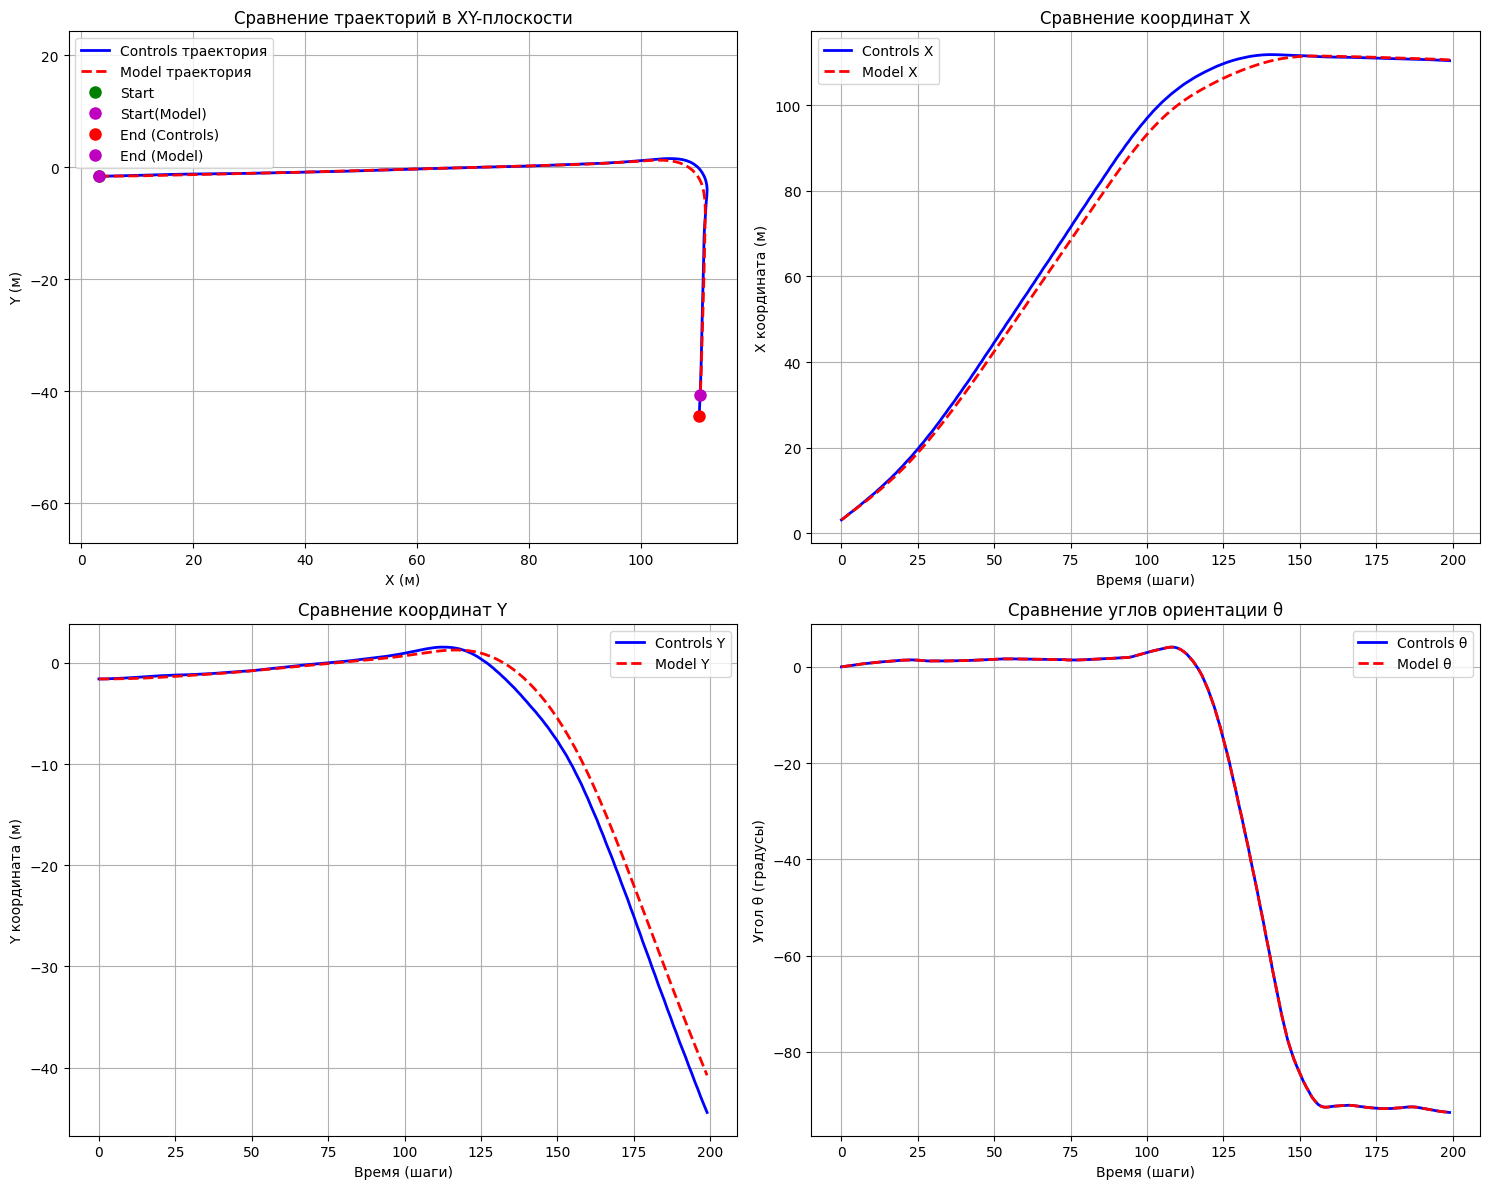

/tmp/ipython-input-2315326292.py:73: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


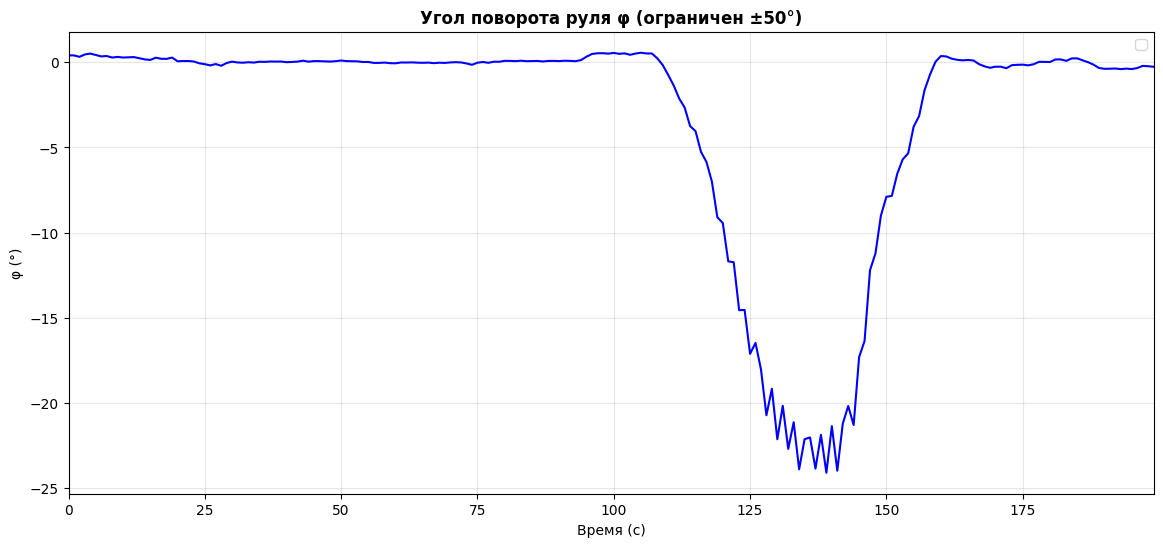

МЕТРИКИ СРАВНЕНИЯ ТРАЕКТОРИЙ
RMSE по X: 2.2269 м
RMSE по Y: 1.6463 м
Общий RMSE: 2.7693 м
Максимальная ошибка по X: 3.8303 м
Максимальная ошибка по Y: 3.6815 м
Конечная позиция Controls: (110.39, -44.43) м
Конечная позиция Model:    (110.58, -40.76) м
Расстояние между конечными точками: 3.6748 м


In [19]:

# Создаём all_states = (n, 5): [x, y, teta, vf, phi]
# Моделируем траекторию
X_state_model = simulate_trajectory_from_controls(all_states, l_car=l_car, dt=dt)

print(f"Размерность входных данных: {all_states.shape}")
print(f"Размерность выходной траектории: {X_state_model.shape}")
print(f"Начальная точка: {X_state_model[0]}")
print(f"Конечная точка: {X_state_model[-1]}")

# Визуализируем результаты
plot_trajectory_comparison(all_states[0: 200], X_state_model[0: 200])

In [ ]:
num = -1000
print(X_state_model[num, 0], all_states[num,0])
X_state_model[num, 0] - all_states[num,0]

241.80360954414385 169.2864279265748


np.float64(72.51718161756907)

In [ ]:
print(X_state_model_center[num, 0], all_states[num,0])
X_state_model_center[num, 0] - all_states[num,0]

161.3409469651704 172.33967647193614


np.float64(-10.998729506765756)

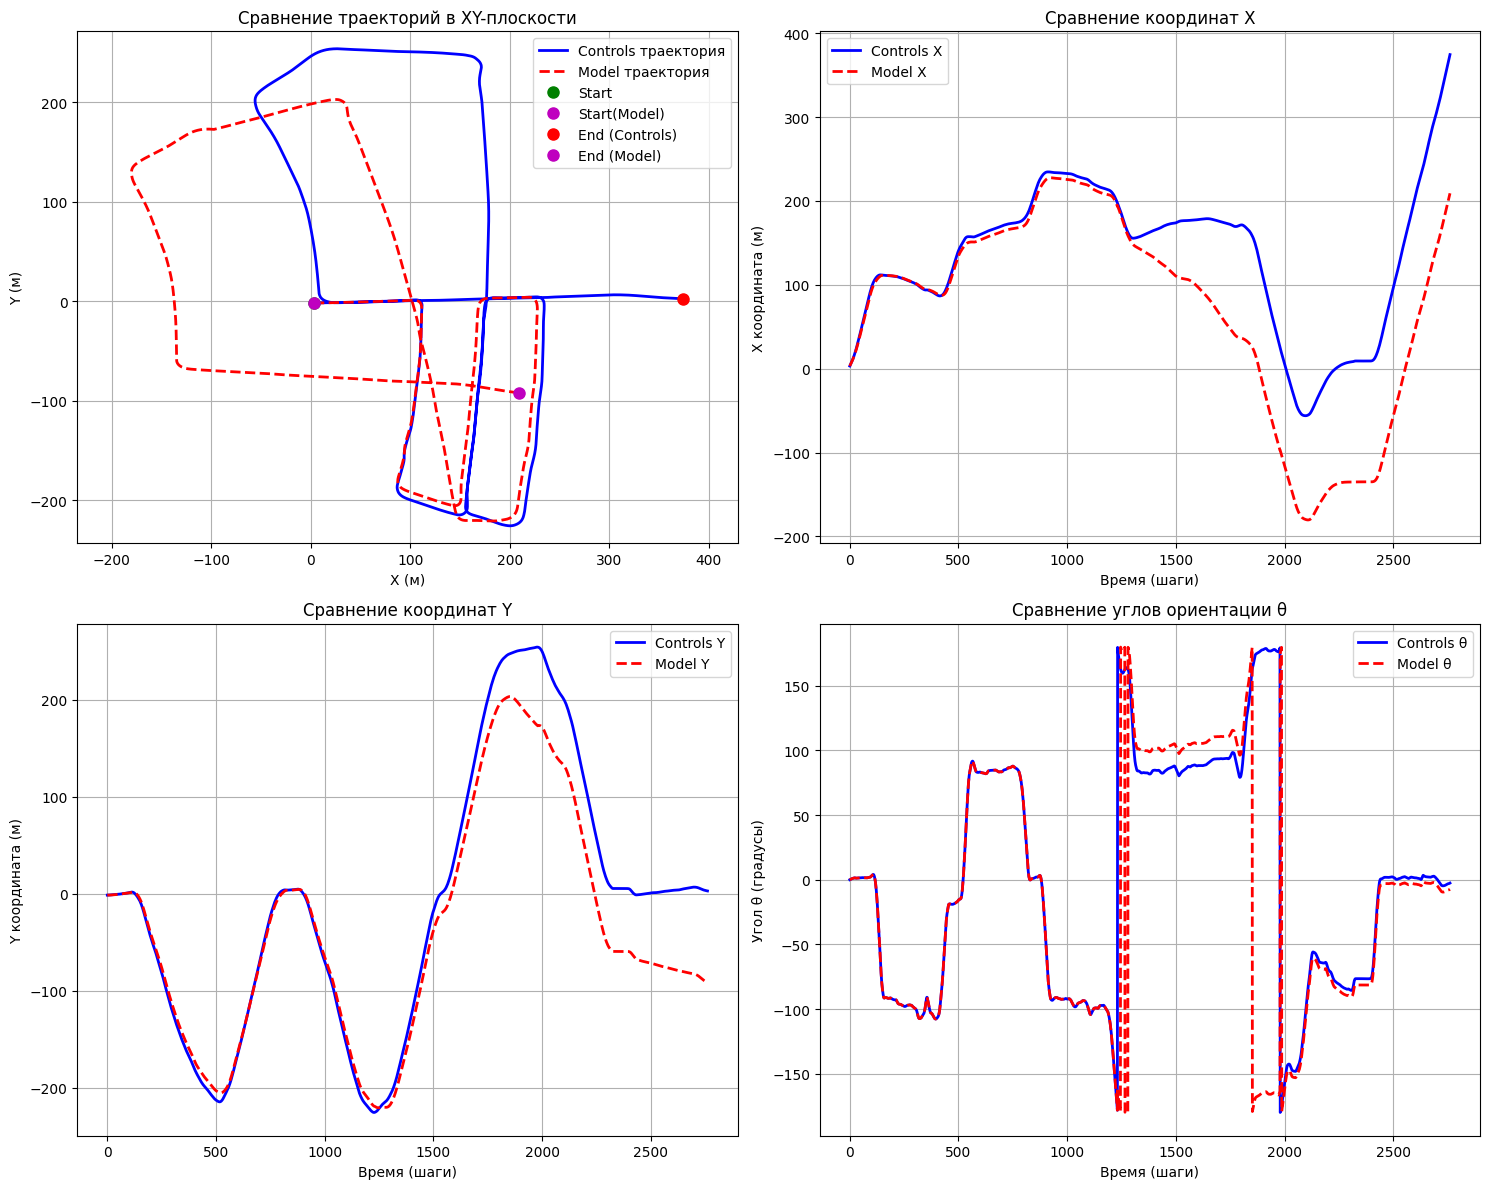

/tmp/ipython-input-2315326292.py:73: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


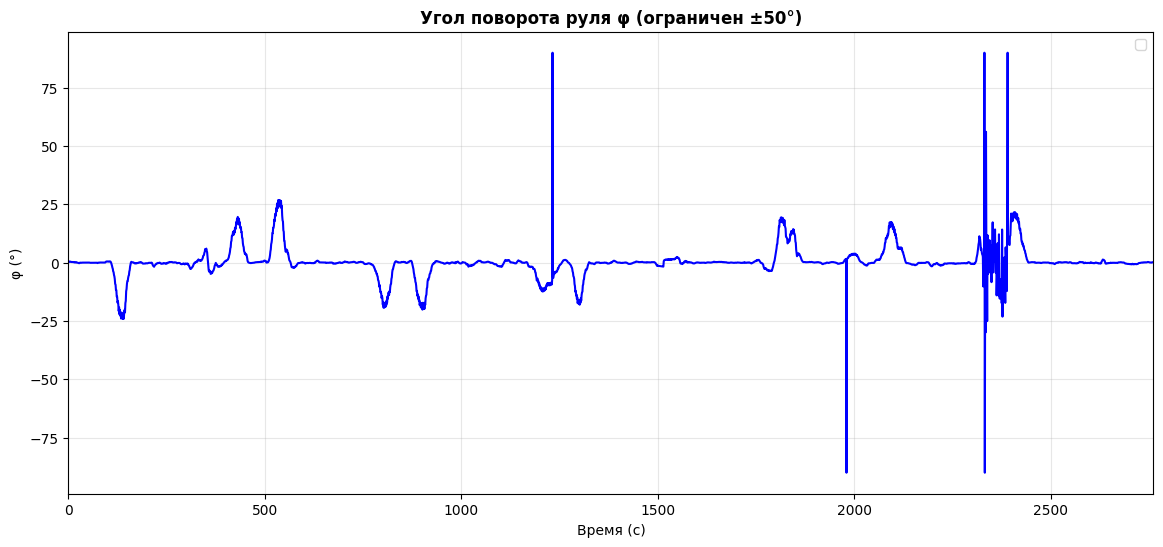

МЕТРИКИ СРАВНЕНИЯ ТРАЕКТОРИЙ
RMSE по X: 90.5862 м
RMSE по Y: 43.4587 м
Общий RMSE: 100.4715 м
Максимальная ошибка по X: 165.3328 м
Максимальная ошибка по Y: 94.6846 м
Конечная позиция Controls: (374.42, 2.70) м
Конечная позиция Model:    (209.09, -91.98) м
Расстояние между конечными точками: 190.5259 м


In [20]:
plot_trajectory_comparison(all_states[0:], X_state_model[0:])

### странности

In [ ]:
a = 2300
b = 2400
#plot_vehicle_states_custom(state_X[a:b])

In [ ]:
indices = np.where(vf_valid < 0)[0]
print("Индексы с отрицательной скоростью:", indices)
print("Значения скорости:", vf_valid[indices])

Индексы с отрицательной скоростью: [2328 2329 2330 2331 2332 2335 2336 2337 2338 2339 2340 2341 2342 2343
 2344 2345 2346 2347 2348 2349 2350 2351 2352 2353 2354 2355 2356 2357
 2358 2359 2360]
Значения скорости: [-0.12499293 -0.09297761 -0.00324817 -0.01015885 -0.02527356 -0.02627915
 -0.01790037 -0.00357908 -0.01193937 -0.01815186 -0.01214026 -0.00864852
 -0.01450482 -0.01392503 -0.00785457 -0.01019971 -0.0121337  -0.00814909
 -0.00704264 -0.00899233 -0.00755802 -0.00464048 -0.00559947 -0.005707
 -0.00343813 -0.0032853  -0.00382554 -0.00217738 -0.00114477 -0.00193971
 -0.00095649]


In [ ]:
a = 2329
b = 2335
print('Глобальный угол\n', theta[a: b])
print("Скорость\n", vf_valid[a: b])

print("\nUp = dtheta\n", dtheta[a:b] * l_car)
print("Down = vf_valid * dt\n", denominator[a:b])
print("Arg\n", arg[a:b])

Глобальный угол
 [-1.33562322 -1.33573052 -1.33624236 -1.33564671 -1.33576484 -1.33596402]
Скорость
 [-0.09297761 -0.00324817 -0.01015885 -0.02527356  0.0030699   0.00072104]

Up = dtheta
 [-0.00029068 -0.00138658  0.00161362 -0.00032002 -0.00053957  0.00089948]
Down = vf_valid * dt
 [-0.00929776 -0.001      -0.00101588 -0.00252736  0.001       0.001     ]
Arg
 [ 0.03126383  1.         -1.          0.12662111 -0.5395734   0.89947941]


In [ ]:
dtheta[:10] * l_car

array([0.00422262, 0.00332665, 0.00476859, 0.00525429, 0.00442697,
       0.00359209, 0.003887  , 0.00299437, 0.00343175, 0.00307994])

In [ ]:
nan_indices = np.where(np.isnan(arr_phi))[0]
print("Индексы с NaN:", nan_indices)

Индексы с NaN: [2330 2331 2389]


GPS-координаты:


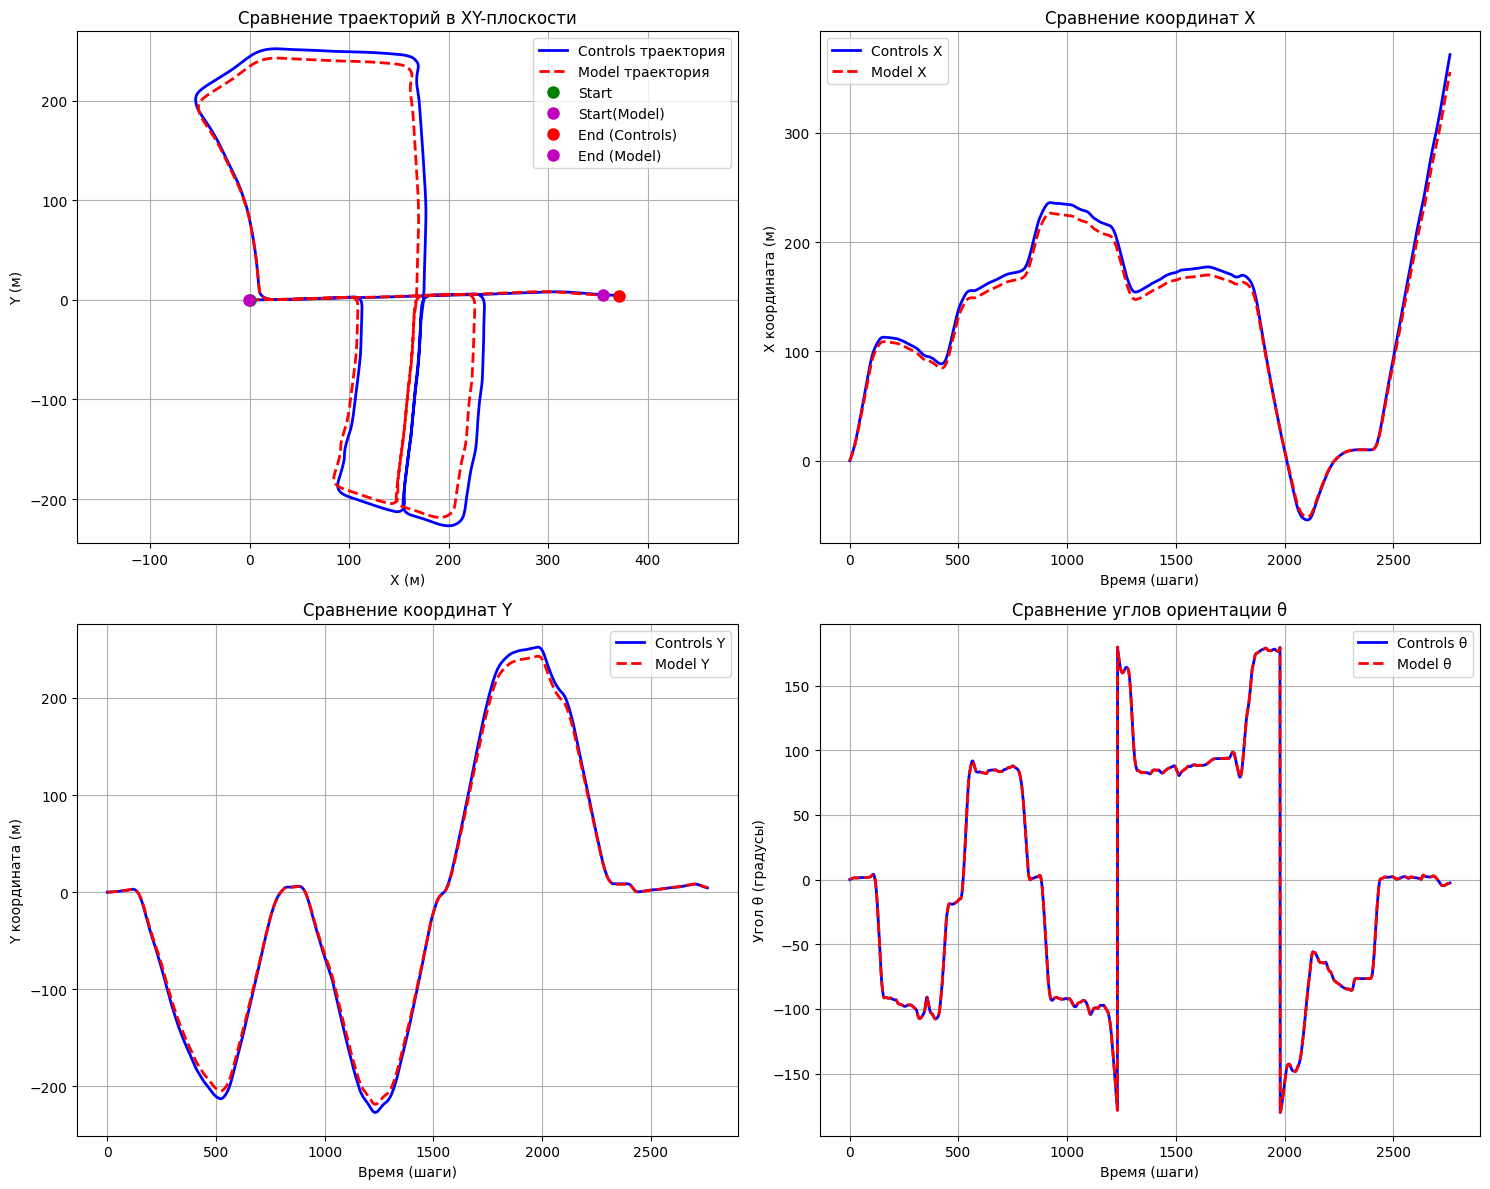

МЕТРИКИ СРАВНЕНИЯ ТРАЕКТОРИЙ
RMSE по X: 6.6685 м
RMSE по Y: 5.1805 м
Общий RMSE: 8.4443 м
Максимальная ошибка по X: 15.8217 м
Максимальная ошибка по Y: 9.4319 м
Конечная позиция Controls: (371.37, 4.43) м
Конечная позиция Model:    (355.57, 4.83) м
Расстояние между конечными точками: 15.8069 м


In [ ]:
def transform_to_gps_coords(X_state_model: np.ndarray,
                            l_off: float = 1.2,
                            alpha: float = 0.0) -> np.ndarray:
    """
    Преобразует состояние автомобиля (x, y, theta) в координаты GPS-антенны.

    Формулы:
        x_GPS = x - l_off * cos(theta - alpha)
        y_GPS = y - l_off * sin(theta - alpha)
        theta_GPS = theta

    Args:
        X_state_model : np.ndarray, shape (n, 5)
            Массив состояний [x, y, theta, vf, phi]
        l_off : float
            Расстояние от центра машины до GPS-антенны (в метрах). По умолчанию 1.2 м.
        alpha : float
            Угол смещения антенны относительно продольной оси машины (в радианах).
            По умолчанию 0 — антенна спереди по оси движения.

    Returns:
        X_gps : np.ndarray, shape (n, 3)
            Массив координат GPS: [x_gps, y_gps, theta_gps]
    """
    # Извлекаем x, y, theta
    x = X_state_model[:, 0]   # x-координата центра машины
    y = X_state_model[:, 1]   # y-координата центра машины
    theta = X_state_model[:, 2]  # угол поворота машины (yaw)

    # Вычисляем смещение в системе координат машины
    dx = l_off * np.cos(theta - alpha)
    dy = l_off * np.sin(theta - alpha)

    # Переводим в GPS-координаты
    x_gps = x - dx
    y_gps = y - dy
    theta_gps = theta  # угол не меняется

    # Собираем результат
    X_gps = np.column_stack([x_gps, y_gps, theta_gps])

    return X_gps


# Преобразуем в GPS-координаты
X_gps = transform_to_gps_coords(X_state_model, l_off=l_off, alpha=alpha)

print("GPS-координаты:")
#print(X_gps)
plot_trajectory_comparison(all_states[:], X_gps[:])